In [6]:
import numpy as np
import torch
from torch import nn
import torch.optim as optim
from torch.distributions.categorical import Categorical
import gymnasium as gym
import matplotlib.pyplot as plt

In [7]:
# Actor network
class Actor(nn.Module):
  def __init__(self, state_size, action_size):
    super().__init__()
    self.anet = nn.Sequential(
        nn.Linear(state_size, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, action_size)
    )

  def forward(self, x):
    return self.anet(x)

# Critic network
class Critic(nn.Module):
  def __init__(self, state_size):
    super().__init__()
    self.cnet = nn.Sequential(
        nn.Linear(state_size, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, 1)
    )

  def forward(self, x):
    return self.cnet(x)

In [8]:
# instantiate the env & network
env = gym.make("CartPole-v1")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
actor = Actor(state_size, action_size)
critic = Critic(state_size)
# hyperparamters
gamma = 0.99
lr=1e-3
n_steps = 5

# define optimizer
actor_optimizer = optim.Adam(actor.parameters(), lr=lr)
critic_optimizer = optim.Adam(critic.parameters(), lr=lr)
# define loss function for critic
C_criterion = nn.MSELoss()

In [9]:
# obtain probability distribution
def prob_dist(obs):
  logits = actor(obs)
  dist = Categorical(logits=logits) # no tensor output yet, just a distribution object parameterized by those probs
  return dist
# select action
def get_action(obs):
  act = prob_dist(obs).sample()
  return act
# compute TD-target
def get_target(rews, last_v):
  target = torch.zeros_like(rews)
  n = len(rews)
  for i in reversed(range(n)):
    target[i] = rews[i] + (target[i+1] * gamma if i+1 < n else 0) + (gamma * last_v if i == n-1 else 0)
  return target

# optimize function
def optimize(obs, act, rews, last_v):
  logprob = prob_dist(obs).log_prob(act)  # logprob shape:(5,)
  value = critic(obs).squeeze(-1)  # value shape:(5,)
  target = get_target(rews, last_v) # target shape:(5,)
  advantage = target - value # (5,)

  # compute actor & critic loss
  actor_loss = -(logprob * advantage.detach()).mean() # -(log_prob * A(s,a))
  critic_loss = C_criterion(value, target.detach())
  # update actor network
  actor_optimizer.zero_grad()
  actor_loss.backward()
  actor_optimizer.step()
  # update critic network
  critic_optimizer.zero_grad()
  critic_loss.backward()
  critic_optimizer.step()

In [10]:
max_episode = 500
episode_rew = []
# training loop
for i in range(max_episode):
  batch_obs, batch_rew, batch_act = [], [], []
  epi_rew = 0
  obs, _ = env.reset()
  done = False
  obs = torch.tensor(obs, dtype=torch.float32).unsqueeze(0) # shape: (1,4)

  while not done:
    # record first state
    batch_obs.append(obs)
    # take a step
    act = get_action(obs).item()
    next_obs, reward, terminated, truncated, _ = env.step(act)
    done = terminated or truncated
    next_obs = torch.tensor(next_obs, dtype=torch.float32).unsqueeze(0) # shape: (1,4)
    epi_rew += reward

    # record reward & act
    batch_act.append(act)
    batch_rew.append(reward)

    obs = next_obs

    # check if loop reaches n_step or terminal state
    if len(batch_rew) == n_steps or done:
      # last term is V(s_n)(reach n_steps) or 0(done)(scalar tensor)
      R = torch.tensor(0, dtype=torch.float32) if done else critic(obs).squeeze()
      optimize(torch.cat(batch_obs).to(torch.float32),
               torch.tensor(batch_act, dtype=torch.int32),
               torch.tensor(batch_rew, dtype=torch.float32),
               R)
      batch_obs, batch_rew, batch_act = [], [], []
  # record total rewards in an episode
  episode_rew.append(epi_rew)
  print(f'Episode rewards: {epi_rew}')


Episode rewards: 15.0
Episode rewards: 36.0
Episode rewards: 22.0
Episode rewards: 39.0
Episode rewards: 13.0
Episode rewards: 22.0
Episode rewards: 15.0
Episode rewards: 20.0
Episode rewards: 25.0
Episode rewards: 19.0
Episode rewards: 30.0
Episode rewards: 32.0
Episode rewards: 24.0
Episode rewards: 25.0
Episode rewards: 39.0
Episode rewards: 11.0
Episode rewards: 18.0
Episode rewards: 25.0
Episode rewards: 13.0
Episode rewards: 21.0
Episode rewards: 15.0
Episode rewards: 33.0
Episode rewards: 9.0
Episode rewards: 33.0
Episode rewards: 18.0
Episode rewards: 15.0
Episode rewards: 17.0
Episode rewards: 13.0
Episode rewards: 19.0
Episode rewards: 10.0
Episode rewards: 11.0
Episode rewards: 21.0
Episode rewards: 31.0
Episode rewards: 14.0
Episode rewards: 14.0
Episode rewards: 10.0
Episode rewards: 12.0
Episode rewards: 11.0
Episode rewards: 18.0
Episode rewards: 11.0
Episode rewards: 13.0
Episode rewards: 13.0
Episode rewards: 16.0
Episode rewards: 13.0
Episode rewards: 14.0
Episode rew

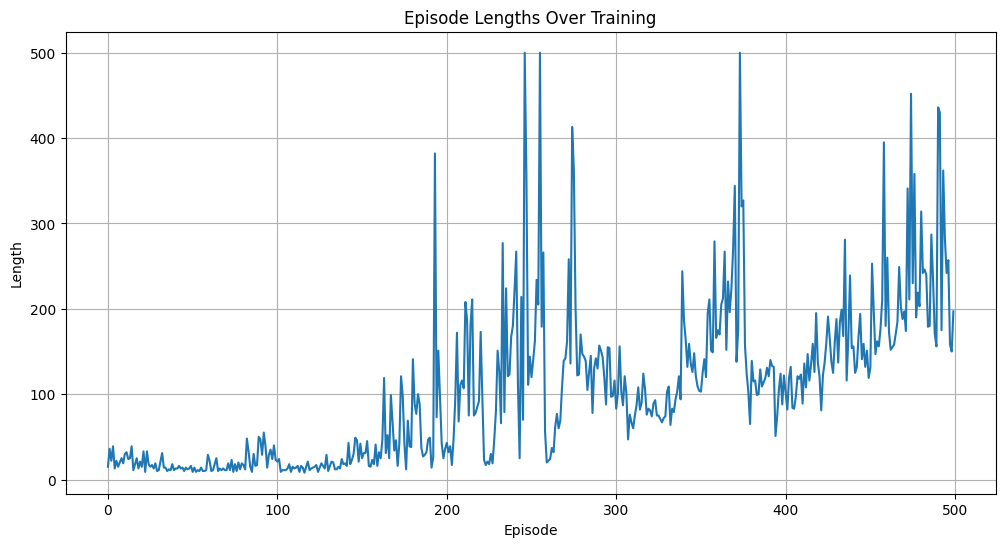

In [11]:
# Plot the collected episode lengths
plt.figure(figsize=(12, 6))
plt.plot(episode_rew)
plt.title('Episode Lengths Over Training')
plt.xlabel('Episode')
plt.ylabel('Length')
plt.grid(True)
plt.show()